File paths successfully generated:
DIRP: f:\OneDrive - alta-rt.com\Documentos\facul\sheep-estrus-thermography\venv\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\windows/release_x64/libdirp.dll
DIRP Sub: f:\OneDrive - alta-rt.com\Documentos\facul\sheep-estrus-thermography\venv\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\windows/release_x64/libv_dirp.dll
IIRP: f:\OneDrive - alta-rt.com\Documentos\facul\sheep-estrus-thermography\venv\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\windows/release_x64/libv_iirp.dll
ExifTool: f:\OneDrive - alta-rt.com\Documentos\facul\sheep-estrus-thermography\venv\Lib\site-packages\dji_executables\dji_thermal_sdk_v1.7\exiftool-12.35.exe


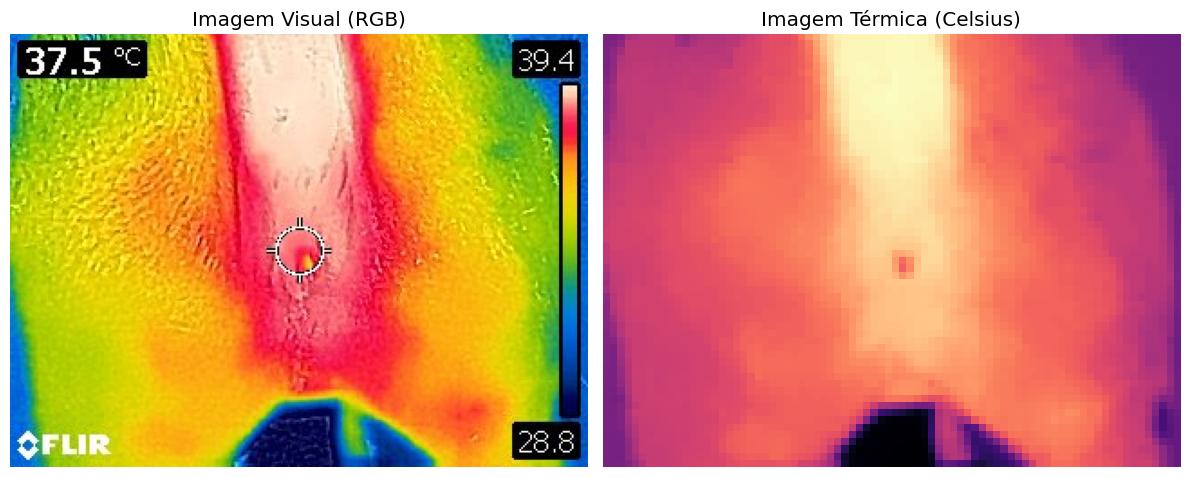

In [1]:
import flirimageextractor
import numpy as np
import matplotlib.pyplot as plt
import cv2

caminho_imagem = '../data/Lote Rosa/Ovelha 2353/FLIR0891.jpg'
img_bgr = cv2.imread(caminho_imagem)
img_cinza = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

altura, largura = img_cinza.shape
corte_y_inicio, corte_y_fim = int(altura * 0.10), int(altura * 0.85)
corte_x_inicio, corte_x_fim = int(largura * 0.10), int(largura * 0.80)

flir = flirimageextractor.FlirImageExtractor()
flir.process_image(caminho_imagem)
matriz_celsius = flir.get_thermal_np()
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Imagem Visual (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(matriz_celsius, cmap='magma')
plt.title('Imagem Térmica (Celsius)')
plt.axis('off')

plt.tight_layout()
plt.show()



MÉTRICAS REAIS (Top 5% em toda a imagem):


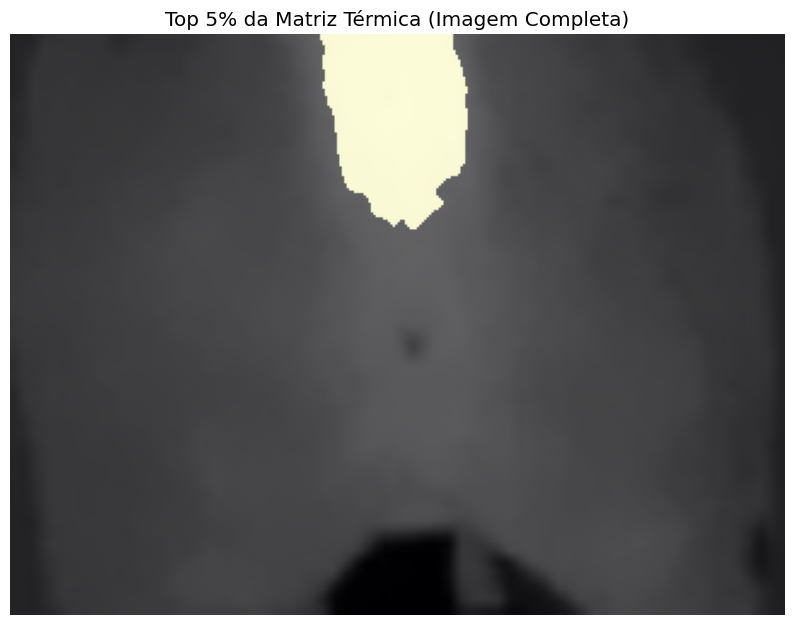

In [34]:

altura_vis, largura_vis = img_cinza.shape
matriz_celsius_hd = cv2.resize(matriz_celsius, (largura_vis, altura_vis), interpolation=cv2.INTER_CUBIC)

percentil_90_celsius = np.percentile(matriz_celsius_hd, 95)

mascara_quente_real = matriz_celsius_hd >= percentil_90_celsius


print("MÉTRICAS REAIS (Top 5% em toda a imagem):")

plt.figure(figsize=(10, 8))
plt.imshow(matriz_celsius_hd, cmap='gray')
plt.imshow(mascara_quente_real, cmap='magma', alpha=0.6)
plt.title(f'Top 5% da Matriz Térmica (Imagem Completa)')
plt.axis('off')
plt.show()

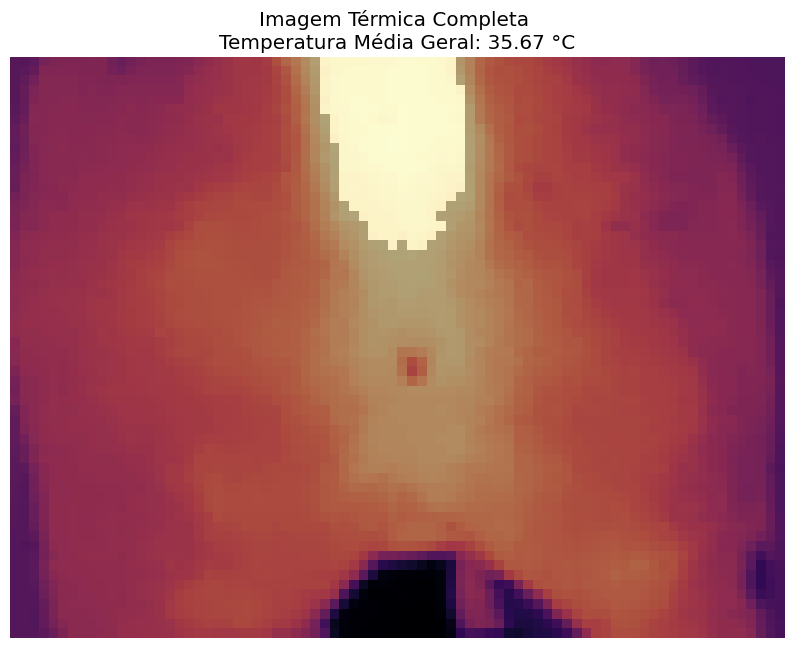

In [3]:

matriz_completa = matriz_celsius

percentil_90 = np.percentile(matriz_completa, 95)
mascara_completa = matriz_completa >= percentil_90

plt.figure(figsize=(10, 8))

plt.imshow(matriz_completa, cmap='magma')

plt.imshow(mascara_completa, cmap='gray', alpha=0.3)

plt.title(f'Imagem Térmica Completa \nTemperatura Média Geral: {np.mean(matriz_completa):.2f} °C')
plt.axis('off')
plt.show()